# Predictive Maintenance using Machine Learning

An end-to-end machine learning project that predicts industrial machine failures from sensor data (AI4I 2020 Predictive Maintenance Dataset). The notebook covers EDA, preprocessing pipelines, model comparison, cross-validation, hyperparameter tuning, feature importance, and model persistence.

##  Table of Contents

1. Business Understanding
2. Dataset Overview & Initial Inspection
3. Exploratory Data Analysis
4. Data Preprocessing
5. Model Comparison
6. Cross Validation
7. Hyperparameter Tuning
8. Feature Importance
9. Model Persistence
10. Conclusions

## 1. Business Problem

Unexpected machine failures lead to costly downtime, production delays, and increased maintenance costs. This project develops a machine learning model that predicts failures from sensor data, enabling maintenance teams to intervene before a breakdown occurs.

## 2. Dataset Overview & Initial Inspection

In [188]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/ai4i2020.csv")

print(df.head())
print(df.shape)
print(df.columns.tolist())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [189]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [190]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [191]:
# There are no missing values in this dataset
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [192]:
# Based on the results, the dataset is imbalanced as over 96% of the machines are healthy while only about 4% are faulty
healthy = df[df["Machine failure"] == 0].shape[0]
failure = df[df["Machine failure"] == 1].shape[0]
print("Healthy machines: ", healthy)
print("Failed machines: ", failure)
print("Percentage of healthy machines: ", healthy / (healthy + failure) * 100)
print("Percentage of failed machines: ", failure / (healthy + failure) * 100)




Healthy machines:  9661
Failed machines:  339
Percentage of healthy machines:  96.61
Percentage of failed machines:  3.39


## 3. Exploratory Data Analysis (EDA)

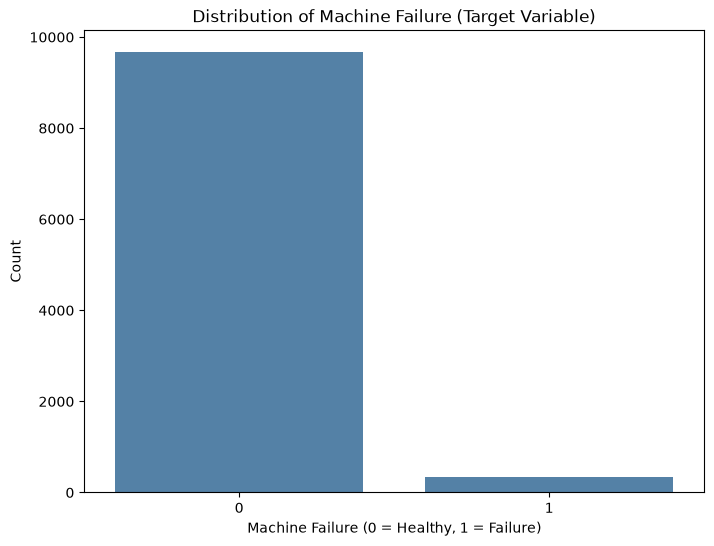

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (8,6))
sns.countplot(x='Machine failure', data=df, color ='steelblue')
plt.title('Distribution of Machine Failure (Target Variable)')
plt.xlabel('Machine Failure (0 = Healthy, 1 = Failure)')
plt.ylabel('Count')
plt.savefig("../images/01_target_distribution.png")
plt.show()

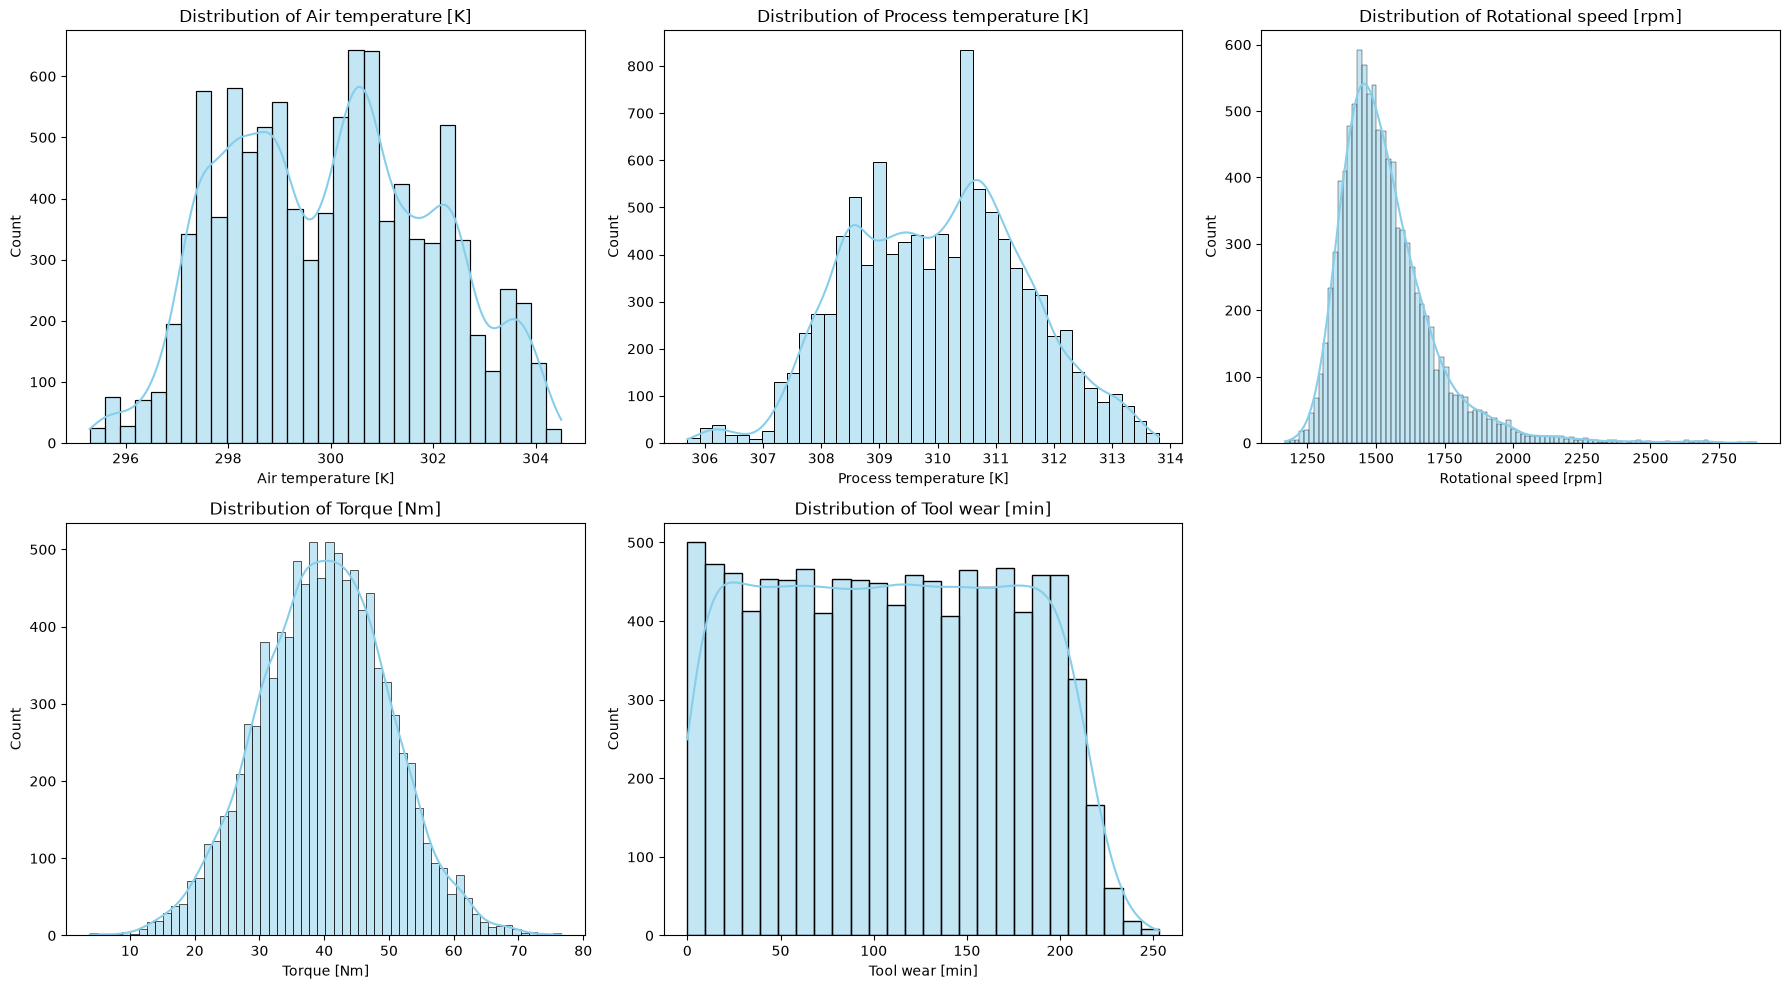

In [194]:
sensor_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, sensor_features):
    sns.histplot(data=df, x=feature, kde=True, color="skyblue", ax=ax)
    ax.set_title(f"Distribution of {feature}")

# Hide the unused 6th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("../images/02_sensor_distributions.png")
plt.show()


### Key Insights
- **Distinct failure signatures:** the "Faulty" and "Healthy" distributions do not perfectly overlap. Shifts in the KDE peaks for Torque and Tool Wear indicate these sensors capture physical states associated with impending failure.
- **Increased instability:** faulty distributions consistently show broader spreads or secondary humps (bimodality) compared to the sharper, more concentrated peaks of healthy machines.
- **Complex decision boundaries:** because the KDE curves for the two classes overlap significantly, a simple threshold rule (e.g. "if Torque > 50, then Failure") would produce many errors — predictive accuracy depends on capturing interactions between sensors rather than any single variable.

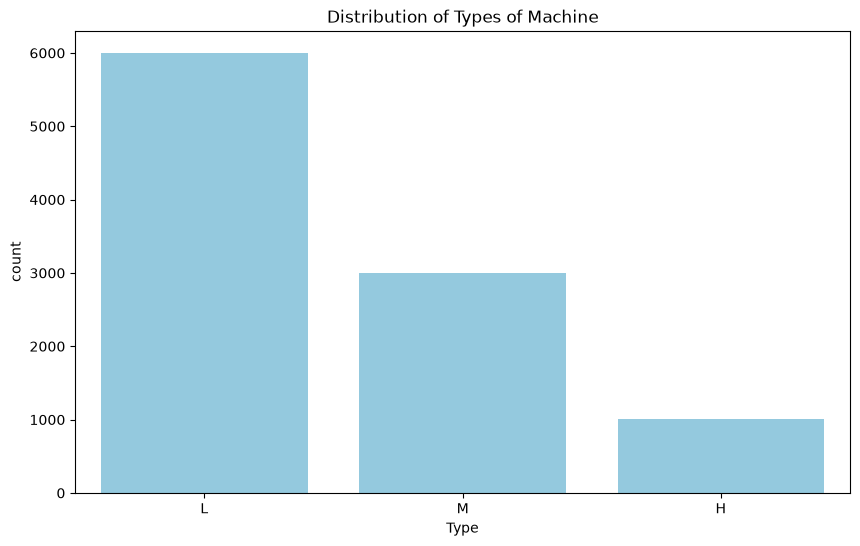

In [195]:
plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'Type', data = df, order=['L', 'M', 'H'], color = 'skyblue')
plt.title("Distribution of Types of Machine")
plt.savefig("../images/03_type_distribution.png")

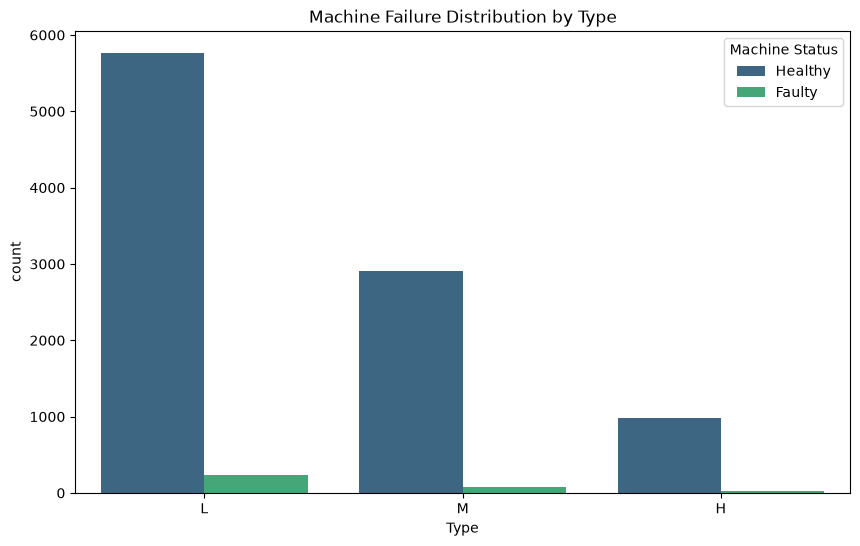

In [196]:
plt.figure(figsize=(10, 6))


ax = sns.countplot(x='Type', hue='Machine failure', order=['L', 'M', 'H'], data=df, palette='viridis')

ax.legend(title='Machine Status', labels=['Healthy', 'Faulty'])

plt.title('Machine Failure Distribution by Type')

plt.savefig("../images/04_machine_failure_by_type.png")
plt.show()

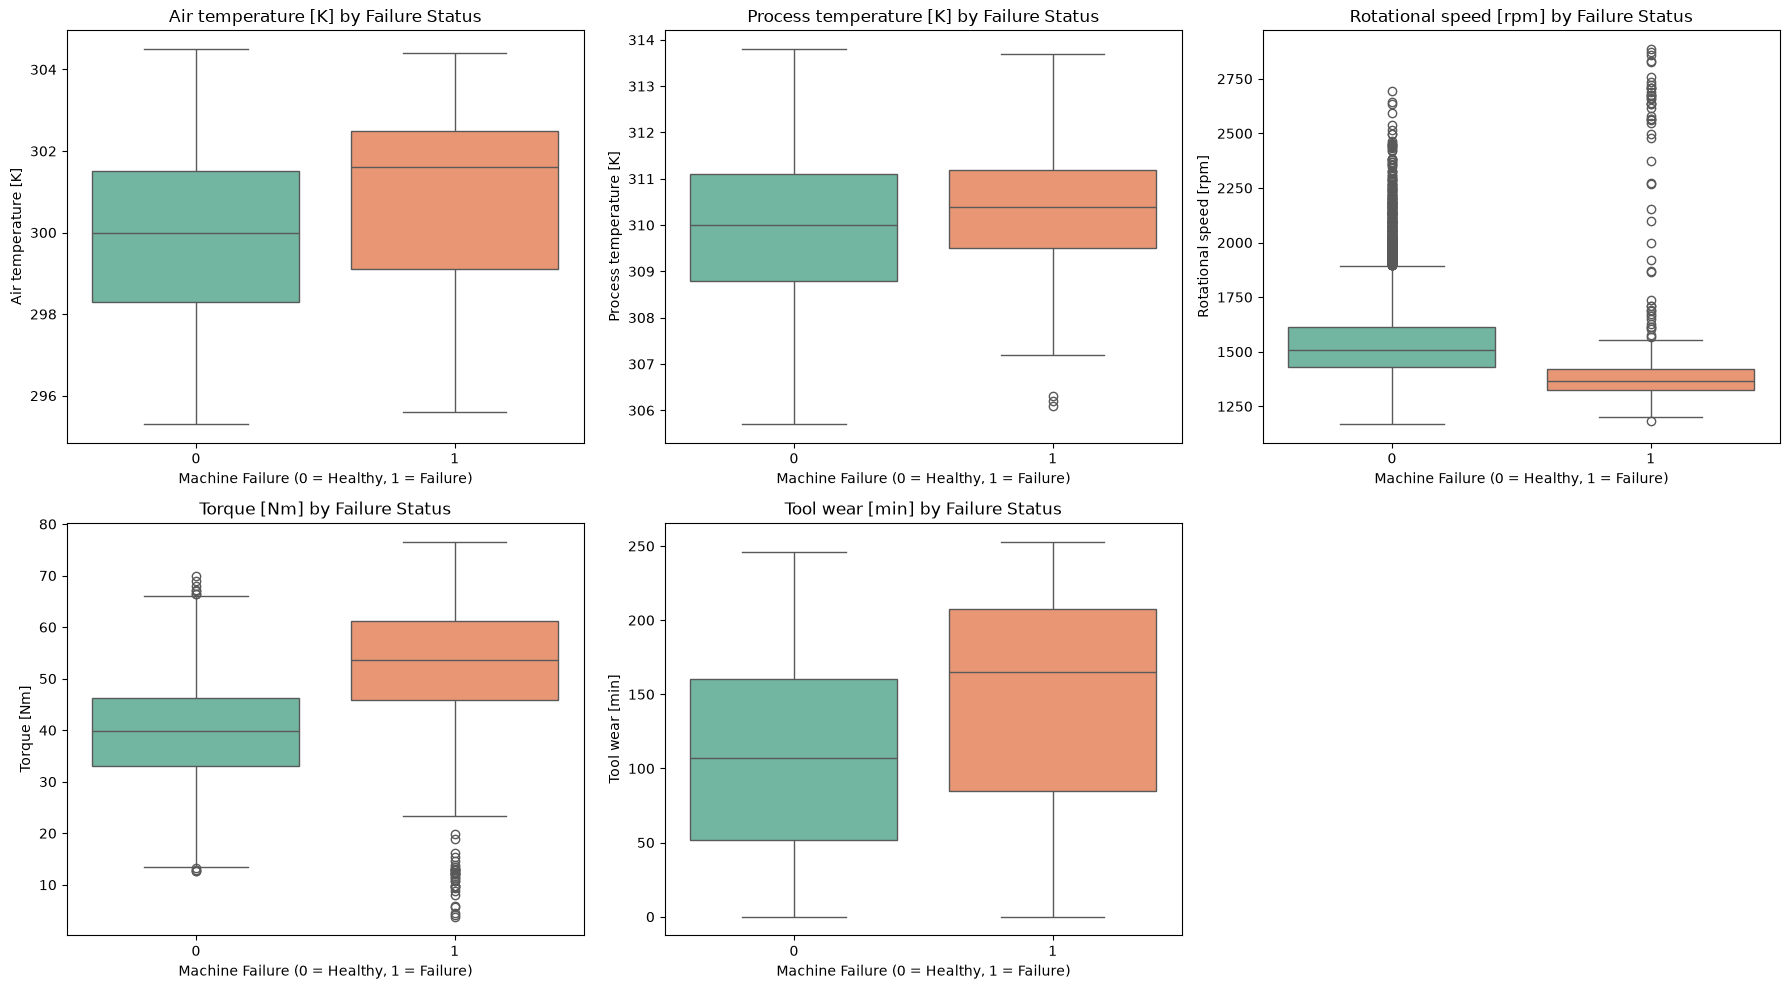

In [197]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, sensor_features):
    sns.boxplot(
        x="Machine failure",
        y=feature,
        hue="Machine failure",
        data=df,
        palette="Set2",
        legend=False,
        ax=ax,
    )
    ax.set_title(f"{feature} by Failure Status")
    ax.set_xlabel("Machine Failure (0 = Healthy, 1 = Failure)")

axes[-1].axis("off")

plt.tight_layout()
plt.savefig("../images/05_boxplots_by_failure.png")
plt.show()


### Key Insights
- **High discriminative power of Torque & Tool Wear:** these two features show the clearest visual separation between healthy and faulty machines, suggesting they are primary indicators of degradation.
- **Increased volatility during failure:** across almost all sensors, faulty machines exhibit wider distributions and more frequent outliers — failure looks like a transition into erratic behavior rather than a single static threshold being crossed.
- **Multi-factor failure signatures:** overlapping distributions confirm that no single sensor perfectly predicts failure, reinforcing the need for tree-based models that can learn non-linear combinations of features.

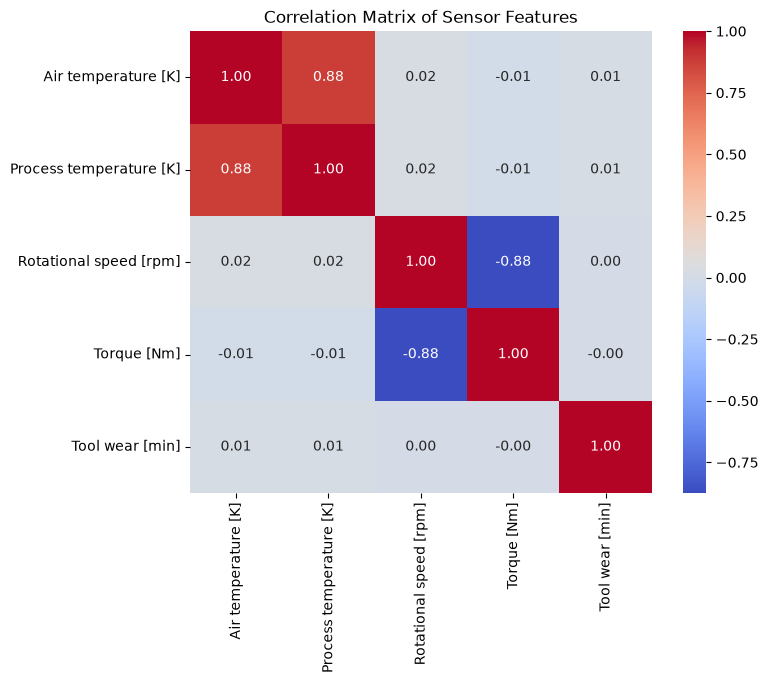

In [198]:
sensor_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df_sensors = df[sensor_features]

corr_matrix = df_sensors.corr()

plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f", square = True)
plt.title("Correlation Matrix of Sensor Features")
plt.savefig("../images/06_correlation_heatmap.png")
plt.show()

In [199]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [200]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


## 4. Data Preprocessing & Pipeline Design

The identifier columns (`UDI`, `Product ID`) and the individual failure-mode flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) are excluded by explicitly selecting only the sensor and type columns as model inputs — the failure-mode flags are a direct decomposition of the target and would leak information if included.

In [201]:
import sklearn
from sklearn.model_selection import train_test_split

features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type']
X = df[features]
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)


In [202]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Machine failure
0    0.966143
1    0.033857
Name: proportion, dtype: float64
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [203]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
categorical_features = ['Type']

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features)
    ]
)

In [204]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

## 5. Model Training

In [205]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

pipelines = {

    "Logistic Regression": Pipeline([
        ('preprocessor', scaled_preprocessor),
        ('classifier', LogisticRegression(random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ('preprocessor', tree_preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ('preprocessor', tree_preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),

    "Gradient Boosting": Pipeline([
        ('preprocessor', tree_preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ]),

    "SVM": Pipeline([
        ('preprocessor', scaled_preprocessor),
        ('classifier', SVC(probability=True, random_state=42))
    ])
}

In [206]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def evaluate_pipeline(name, pipeline, X_train, X_test, y_train, y_test):

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division = 0),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics, pipeline, y_pred, y_prob, cm

In [207]:
results = []
trained_models = {}
predictions = {}
probabilities = {}
confusion_matrices = {}

for name, pipeline in pipelines.items():

    metrics, trained_pipeline, y_pred, y_prob, cm = evaluate_pipeline(
        name,
        pipeline,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results.append(metrics)
    trained_models[name] = trained_pipeline
    predictions[name] = y_pred
    probabilities[name] = y_prob
    confusion_matrices[name] = cm
    
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree


Trained: Random Forest
Trained: Gradient Boosting


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Trained: SVM


## 6. Model Comparison

In [208]:
results_df = pd.DataFrame(results)

# Round metrics to 3 decimal places
results_df = results_df.round(3)

# Sort by Recall (our primary business metric)
results_df = results_df.sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0        Decision Tree     0.976      0.635   0.716     0.673    0.851
1    Gradient Boosting     0.983      0.871   0.598     0.709    0.978
2        Random Forest     0.979      0.845   0.480     0.612    0.973
3                  SVM     0.972      0.875   0.206     0.333    0.943
4  Logistic Regression     0.968      0.609   0.137     0.224    0.881


In [209]:
results_df.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    color="#2ecc71"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.976000,0.635000,0.716000,0.673000,0.851000
1,Gradient Boosting,0.983000,0.871000,0.598000,0.709000,0.978000
2,Random Forest,0.979000,0.845000,0.480000,0.612000,0.973000
3,SVM,0.972000,0.875000,0.206000,0.333000,0.943000
4,Logistic Regression,0.968000,0.609000,0.137000,0.224000,0.881000


In [210]:
results_df.to_csv("../results/model_comparison.csv", index=False)

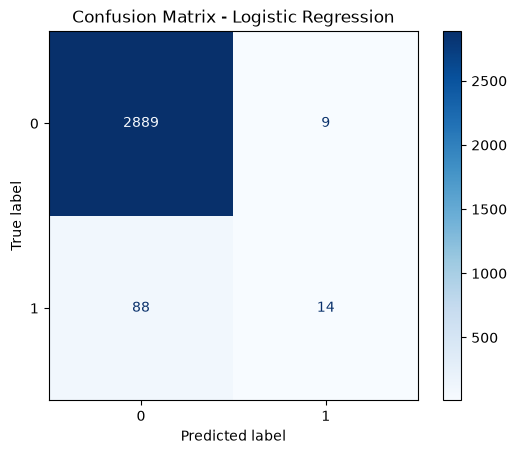

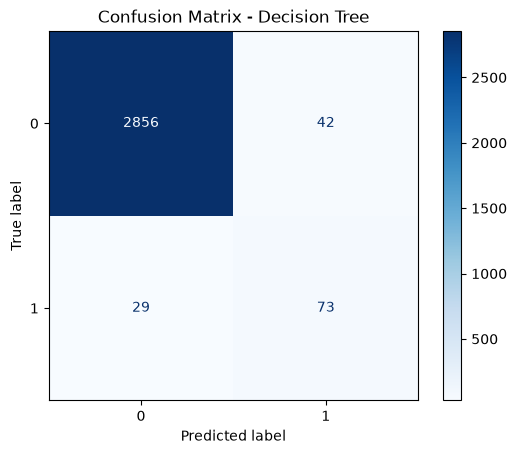

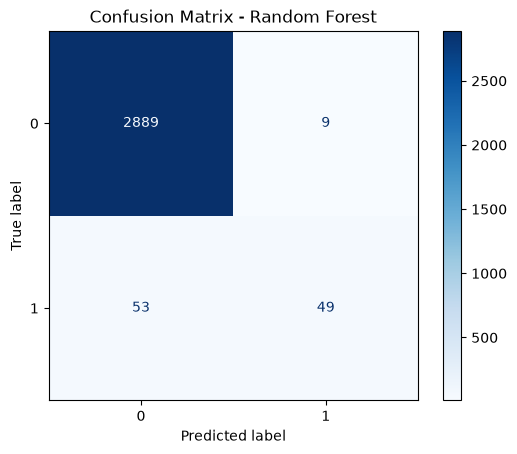

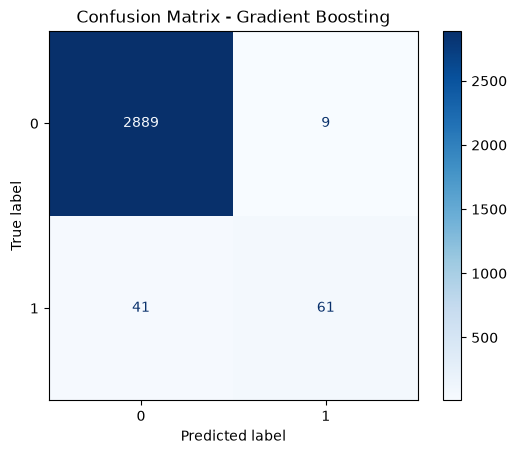

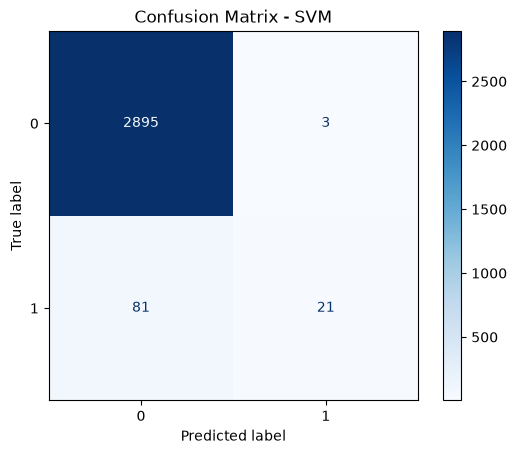

In [211]:
from sklearn.metrics import ConfusionMatrixDisplay

for name in pipelines.keys():

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"../images/07_confusion_matrix_{name.replace(' ', '_').lower()}.png")
    plt.show()

In [212]:
for name, pipeline in trained_models.items():

    print("=" * 60)

    print(name)

    print(classification_report(
        y_test,
        predictions[name]
    ))

Logistic Regression
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2898
           1       0.61      0.14      0.22       102

    accuracy                           0.97      3000
   macro avg       0.79      0.57      0.60      3000
weighted avg       0.96      0.97      0.96      3000

Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2898
           1       0.63      0.72      0.67       102

    accuracy                           0.98      3000
   macro avg       0.81      0.85      0.83      3000
weighted avg       0.98      0.98      0.98      3000

Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2898
           1       0.84      0.48      0.61       102

    accuracy                           0.98      3000
   macro avg       0.91      0.74      0.80      3000
weighted avg       0.98   

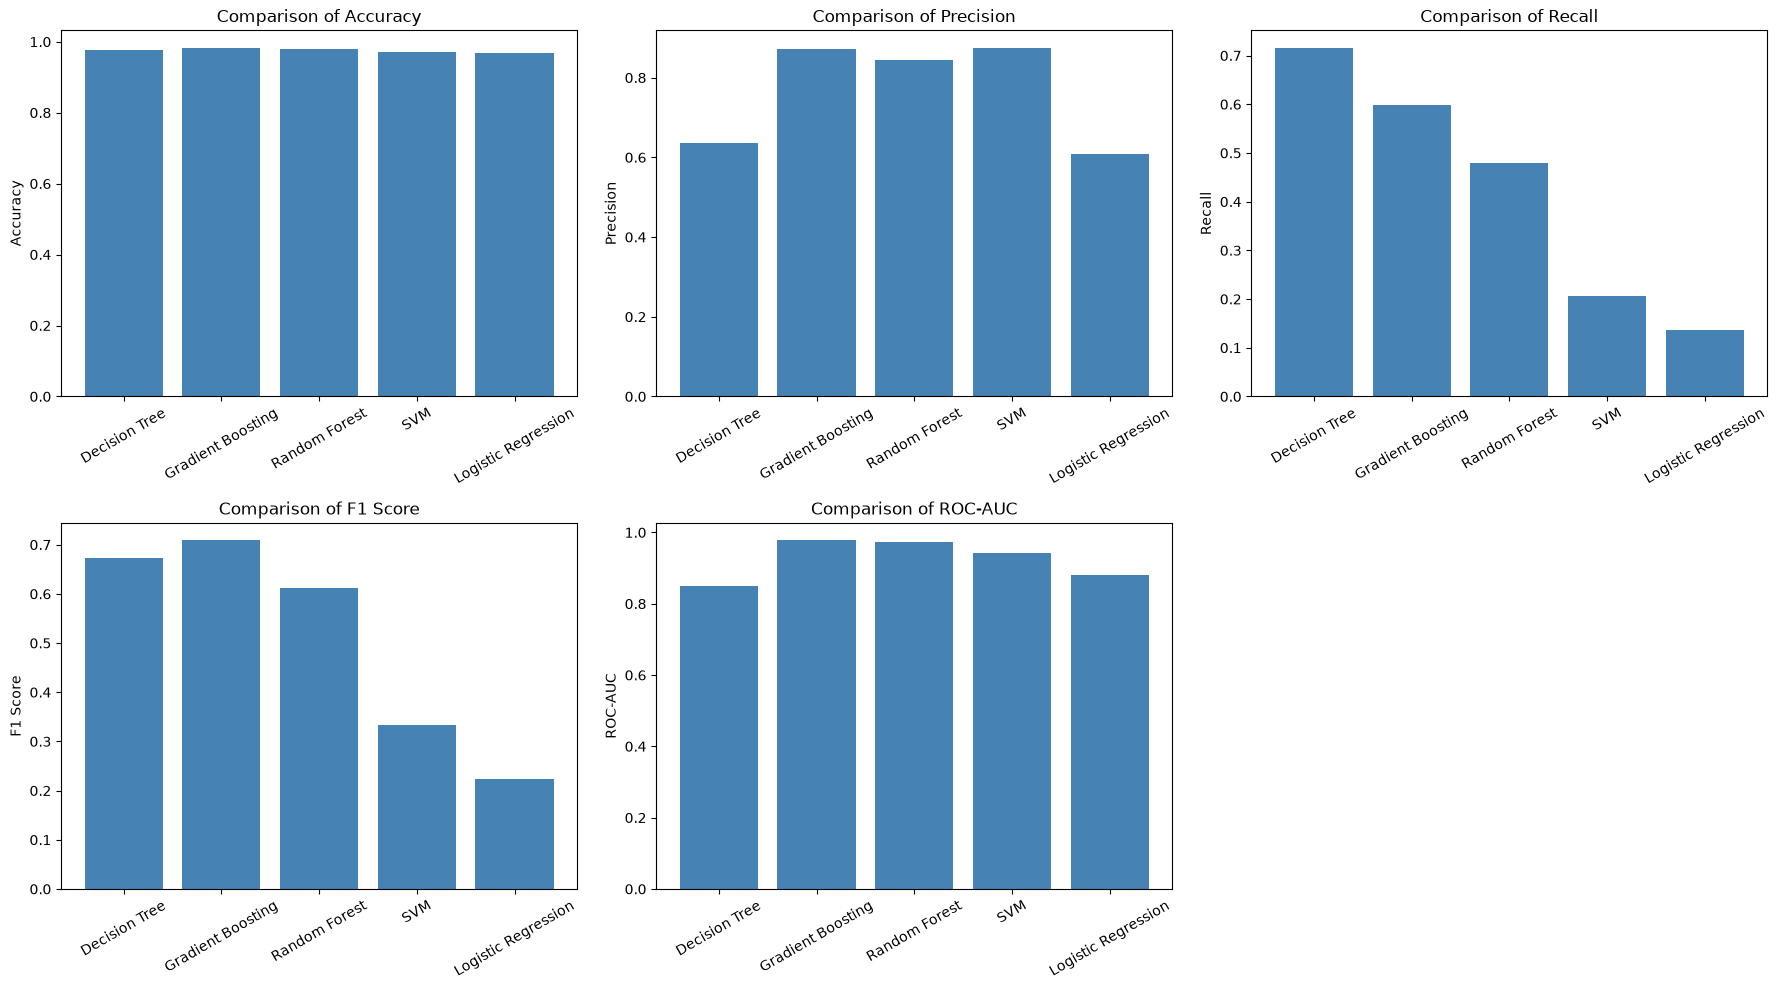

In [213]:
metric_names = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metric_names):
    ax.bar(results_df["Model"], results_df[metric], color="steelblue")
    ax.set_title(f"Comparison of {metric}")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)

axes[-1].axis("off")

plt.tight_layout()
plt.savefig("../images/08_metric_comparison.png")
plt.show()


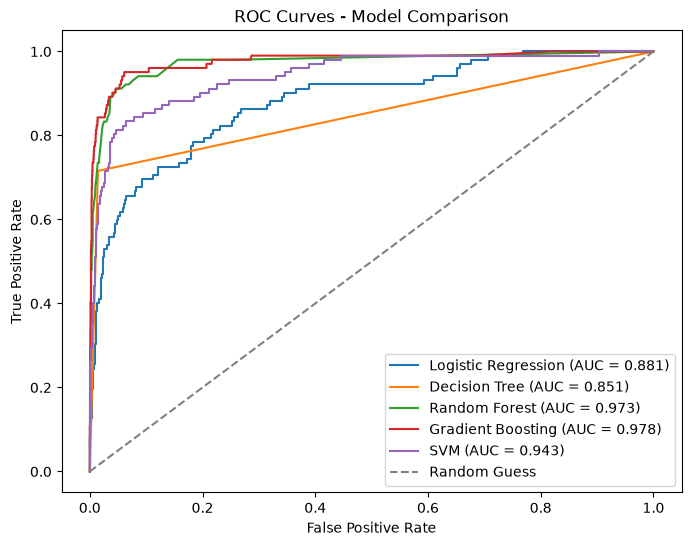

In [214]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name in pipelines.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = results_df.loc[results_df["Model"] == name, "ROC-AUC"].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc="lower right")
plt.savefig("../images/09_roc_curves.png")
plt.show()


### Recall Comparison Across Models

Recall is one of the most important evaluation metrics for predictive maintenance because it measures the proportion of actual machine failures that the model successfully detects.

A higher Recall reduces the likelihood of missing critical equipment failures, making it a more suitable metric than Accuracy for this imbalanced classification problem.

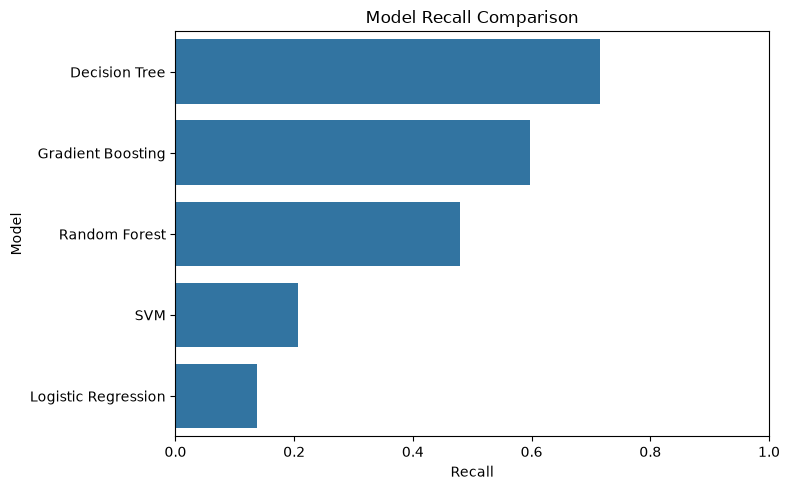

In [215]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df.sort_values("Recall", ascending=False),
    x="Recall",
    y="Model"
)

plt.title("Model Recall Comparison")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig("../images/10_model_recall_comparison.png", dpi=300)

plt.show()

## 7. Cross-Validation
We employ 5-fold stratified cross-validation to ensure our performance metrics are robust rather than artifacts of a single data split.

By training and evaluating the model across different subsets while preserving the original class distribution, this method provides a more reliable performance estimate and reduces the risk of bias from any single, potentially unrepresentative, train-test split.

In [216]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [217]:
cv_results = []

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean()
    })
    
cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,Recall Std,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.9699,0.001655,0.724507,0.185777,0.047741,0.292450,0.895767
1,Decision Tree,0.9758,0.001939,0.640685,0.652019,0.043450,0.645858,0.819592
2,Random Forest,0.9812,0.001077,0.894656,0.507419,0.049235,0.645149,0.963271
3,Gradient Boosting,0.9846,0.003216,0.873769,0.640255,0.105872,0.733508,0.971542
4,SVM,0.9743,0.001122,0.916606,0.268393,0.034951,0.413347,0.948693


In [218]:
cv_result_df = cv_results_df.round(3)

cv_results_df = cv_results_df.sort_values(
    by="Recall Mean",
    ascending=False
)

cv_result_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,Recall Std,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.970,0.002,0.725,0.186,0.048,0.292,0.896
1,Decision Tree,0.976,0.002,0.641,0.652,0.043,0.646,0.820
2,Random Forest,0.981,0.001,0.895,0.507,0.049,0.645,0.963
3,Gradient Boosting,0.985,0.003,0.874,0.640,0.106,0.734,0.972
4,SVM,0.974,0.001,0.917,0.268,0.035,0.413,0.949


In [219]:
cv_result_df.to_csv("../results/cross_validation_results.csv", index=False)

## 8. Hyperparameter Tuning

Among all the evaluated models, **Gradient Boosting** achieved the best overall performance, making it the most suitable candidate for hyperparameter tuning.

To further enhance its predictive capability, **GridSearchCV** is used to evaluate different combinations of hyperparameters through cross-validation.

The search is optimized for **Recall** because, in a predictive maintenance setting, failing to identify an actual machine failure is significantly more costly than generating a false alarm that results in an unnecessary inspection.

In [220]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
    "classifier__subsample": [0.8, 1.0]
}

In [221]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=pipelines["Gradient Boosting"],
    param_grid=param_grid,
    scoring="recall",          # Prioritize catching failures
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [222]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [100, 200, ...], 'classifier__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multipl

In [223]:
print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best CV Recall:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}

Best CV Recall:
0.662145390070922


In [224]:
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_


In [225]:
tuned_metrics, best_model, y_pred_tuned, y_prob_tuned, cm_tuned = evaluate_pipeline(
    "Gradient Boosting (Tuned)",
    best_model,
    X_train,
    X_test,
    y_train,
    y_test
)

# Append and store results
results.append(tuned_metrics)
trained_models["Gradient Boosting (Tuned)"] = best_model
predictions["Gradient Boosting (Tuned)"] = y_pred_tuned
probabilities["Gradient Boosting (Tuned)"] = y_prob_tuned
confusion_matrices["Gradient Boosting (Tuned)"] = cm_tuned

tuned_metrics

{'Model': 'Gradient Boosting (Tuned)',
 'Accuracy': 0.984,
 'Precision': 0.8292682926829268,
 'Recall': 0.6666666666666666,
 'F1 Score': 0.7391304347826086,
 'ROC-AUC': 0.9661040744800335}

In [226]:
import os

results_df = pd.DataFrame(results).round(3)
results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)
results_df.to_csv(os.path.join('../results', "model_comparison.csv"), index=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.976,0.635,0.716,0.673,0.851
1,Gradient Boosting (Tuned),0.984,0.829,0.667,0.739,0.966
2,Gradient Boosting,0.983,0.871,0.598,0.709,0.978
3,Random Forest,0.979,0.845,0.480,0.612,0.973
4,SVM,0.972,0.875,0.206,0.333,0.943
5,Logistic Regression,0.968,0.609,0.137,0.224,0.881


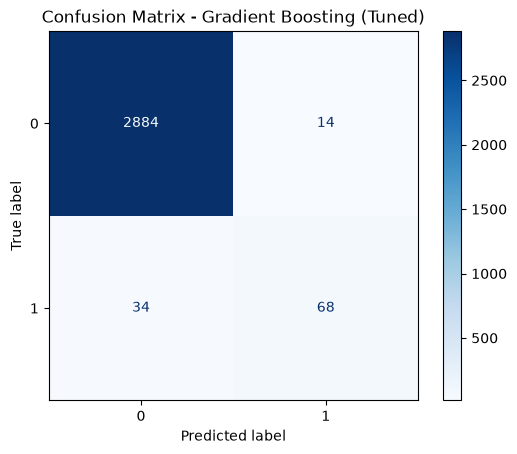

In [227]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting (Tuned)")
plt.savefig("../images/11_confusion_matrix_tuned_model.png")
plt.show()


In [228]:
import json

with open("../models/best_gradient_boosting_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

In [229]:
import joblib

joblib.dump(
    best_model,
    "../models/best_gradient_boosting.pkl"
)

['../models/best_gradient_boosting.pkl']

### Compare Tuned vs Untuned Model

In [230]:
comparison = pd.DataFrame([
    results_df[results_df["Model"] == "Gradient Boosting"].iloc[0].to_dict(),
    tuned_metrics
])

comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.983,0.871,0.598,0.709,0.978
1,Gradient Boosting (Tuned),0.984,0.829,0.667,0.739,0.966


### Precision-Recall Trade-off

Because failures are rare (~3.4% of the data), ROC-AUC can look optimistic. The precision-recall curve gives a more honest picture of performance on the minority (failure) class for the final tuned model.

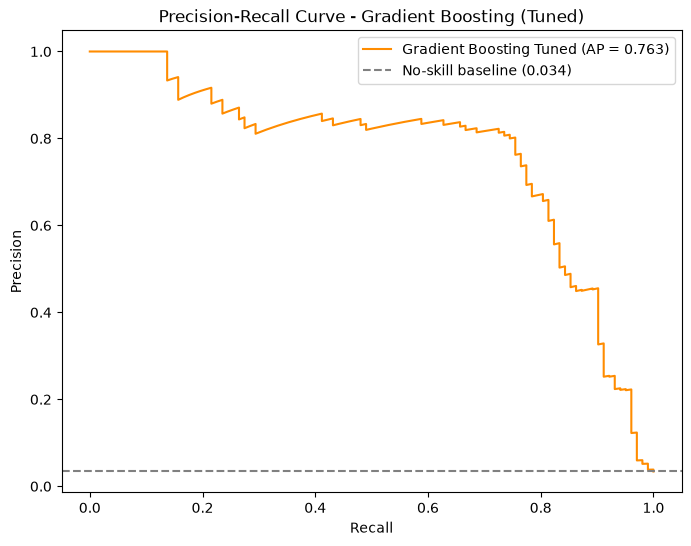

In [231]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob_tuned)
ap_score = average_precision_score(y_test, y_prob_tuned)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color="darkorange", label=f"Gradient Boosting Tuned (AP = {ap_score:.3f})")
baseline = y_test.mean()
plt.axhline(baseline, linestyle="--", color="gray", label=f"No-skill baseline ({baseline:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gradient Boosting (Tuned)")
plt.legend(loc="upper right")
plt.savefig("../images/12_precision_recall_curve.png")
plt.show()


In [232]:
final_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Recall": 0.137
    },
    {
        "Model": "Decision Tree",
        "Recall": 0.716
    },
    {
        "Model": "Random Forest",
        "Recall": 0.480
    },
    {
        "Model": "SVM",
        "Recall": 0.206
    },
    {
        "Model": "Gradient Boosting",
        "Recall": 0.598
    },
    {
        "Model": "Gradient Boosting (Tuned)",
        "Recall": 0.667
    }
])

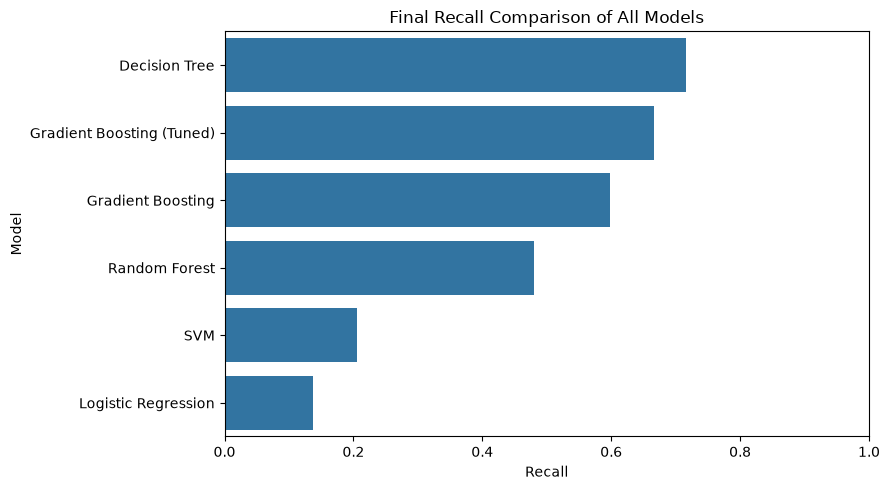

In [233]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=final_results.sort_values("Recall", ascending=False),
    x="Recall",
    y="Model"
)

plt.title("Final Recall Comparison of All Models")

plt.xlim(0, 1)

plt.tight_layout()

plt.savefig("../images/13_final_model_recall_comparison.png", dpi=300)

plt.show()

## 9. Feature Importance

In [234]:
gb_classifier = best_model.named_steps["classifier"]

preprocessor = best_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

importances = gb_classifier.feature_importances_

In [235]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop = True)

importance_df

,Feature,Importance
0,remainder__Torque [Nm],0.370874
1,remainder__Tool wear [min],0.192804
2,remainder__Rotational speed [rpm],0.157797
3,remainder__Air temperature [K],0.119022
4,remainder__Process temperature [K],0.116081
5,cat__Type_L,0.025805
6,cat__Type_M,0.009478
7,cat__Type_H,0.008140


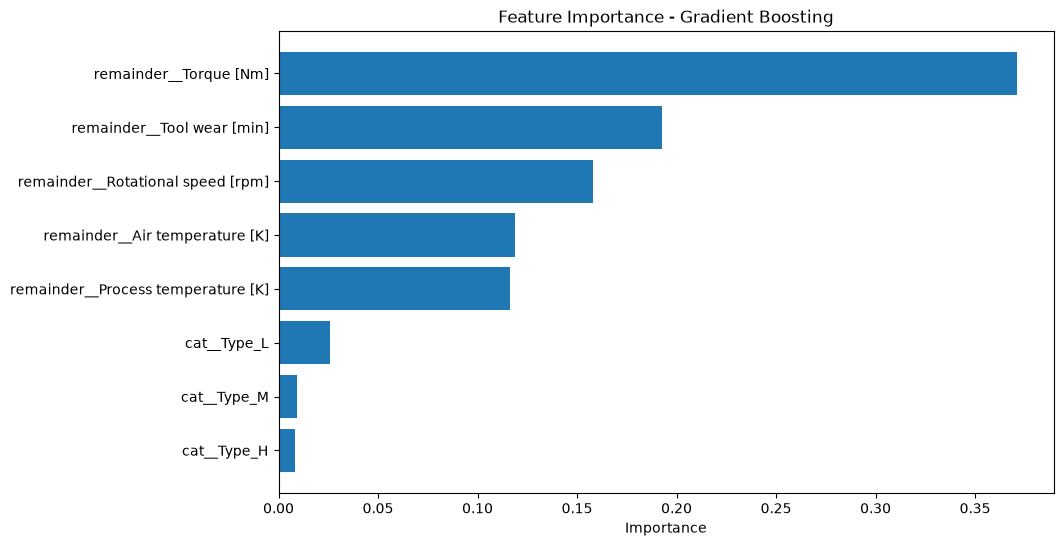

In [238]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.savefig("../images/14_feature_importance.png")
plt.show()

### Interpretation

The feature importance analysis indicates that **Tool Wear**, **Torque**, and **Rotational Speed** contribute the most to predicting machine failures.

These findings align with real-world engineering intuition. Components that experience prolonged wear or operate under higher mechanical stress are naturally more susceptible to failure.

This demonstrates that the model is learning meaningful physical relationships rather than relying on random patterns.

## 10. Model Persistence

In [237]:
loaded_model = joblib.load("../models/best_gradient_boosting.pkl")

sample = X_test.iloc[:5]
loaded_preds = loaded_model.predict(sample)
original_preds = best_model.predict(sample)

print("Loaded model predictions:  ", loaded_preds)
print("Original model predictions:", original_preds)

assert (loaded_preds == original_preds).all(), "Loaded model predictions do not match the original model!"
print("\nPersistence check passed: loaded model produces identical predictions.")

Loaded model predictions:   [0 0 0 0 0]
Original model predictions: [0 0 0 0 0]

Persistence check passed: loaded model produces identical predictions.


## Final Conclusions

This project successfully developed an end-to-end machine learning solution for predictive maintenance using industrial sensor data.

Five classification algorithms were trained and compared using consistent preprocessing pipelines, cross-validation, and multiple evaluation metrics.

Among all evaluated models, the tuned Gradient Boosting classifier achieved the best overall balance between Recall, Precision, and F1-score, making it the preferred model for predictive maintenance applications.

Key findings include:

- Tool Wear, Torque, and Rotational Speed were the strongest predictors of machine failure.
- Tree-based ensemble models significantly outperformed linear models, highlighting the nonlinear nature of machine degradation.
- Accuracy alone was insufficient due to the highly imbalanced dataset, making Recall and F1-score more appropriate evaluation metrics.
- Hyperparameter tuning further improved Recall, allowing the model to detect more machine failures while maintaining strong overall performance.

Overall, this project demonstrates a complete industry-standard machine learning workflow, from business understanding and exploratory data analysis to model selection, optimization, interpretation, and deployment-ready model persistence.

### Business Impact

Deploying this model within a manufacturing environment could enable predictive maintenance strategies by identifying high-risk machines before failures occur.

Potential benefits include:

- Reduced equipment downtime
- Lower maintenance costs
- Improved production efficiency
- Increased operational reliability
- Better maintenance scheduling

Although this project was developed using a public dataset, the same workflow can be adapted to industrial IoT systems where sensor data is continuously collected from production equipment.